<a href="https://colab.research.google.com/github/lynnkaram/health-informatics-projects/blob/main/homework-1-healthcare-data-quality/healthcare_data_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

np.random.seed(42)

In [ ]:
# Here we are going to explore the intersection of data quality, model
# expressivity and data errors

# please copy this code into your own notebook and complete the sections
# as guided by the comments. some of this will be code (marked CODE) others will
# be text (marked TEXT)


In [ ]:
# This is your sythentic data generator function

# sbp = systolic blood pressure
# dpb = diastolic blood pressure

def make_fake_patient_data(n=500,swap_error=0.15):

    # make some random input data
    age = np.random.randint(18, 90, n)
    bmi = np.random.normal(27, 5, n).clip(18, 40)
    hr = np.random.normal(75, 10, n).clip(50, 120)

    # this is the ground truth relationship for the fake data
    # we will see if we can learn the true relationship
    sbp_true = (
        0.5*age + 0.8*bmi + 0.05*age*(bmi) + 90 + np.random.normal(0, 10, n)
    )

    # make dbp ~50 less than sbp.
    dbp_true = sbp_true - np.random.normal(50, 10, n)

    # simluate errors in data entry. 'swap_error' is the fraction where whoever recorded it
    # accidentally swapped SBP and DBP
    # make it more likely the higher dbp is

    dbp_prob = (dbp_true - dbp_true.min()) / (dbp_true.max() - dbp_true.min())
    dbp_prob = dbp_prob / dbp_prob.mean()   # normalize so mean dbp value has "swap_risk"
    swap_mask = np.random.rand(n) < (swap_error * dbp_prob)
    sbp, dbp = sbp_true.copy(), dbp_true.copy()
    sbp[swap_mask], dbp[swap_mask] = dbp[swap_mask], sbp[swap_mask]

    # Assemble DataFrame
    df = pd.DataFrame({
        "age": age,
        "hr": hr.round(0).astype(int),
        "sbp": sbp.round(0).astype(int),
        "dbp": dbp.round(0).astype(int),
        "bmi": bmi.round(1)
    })

    return df

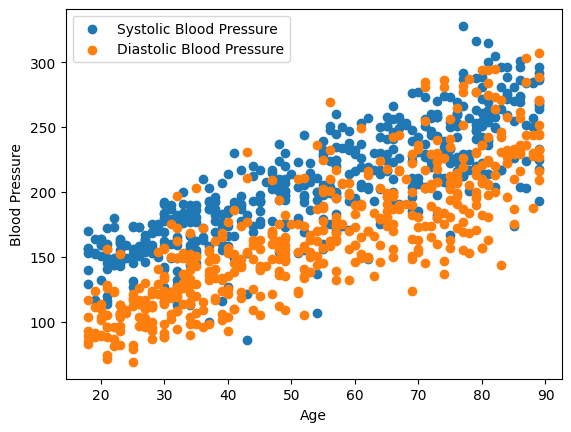

In [ ]:
# make a moderately sized data set using the data set generator (500 patients)
# --CODE--

df = make_fake_patient_data(n=500)
df.head()

# plot age vs SBP and dbp
# --CODE--

import matplotlib.pyplot as plt
plt.scatter(df["age"], df["sbp"], label="Systolic Blood Pressure")
plt.scatter(df["age"], df["dbp"], label="Diastolic Blood Pressure")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()


In [ ]:
# how many patients (count or %) have impossible blood pressure data? (SBP > DBP) #correction: DBP > SBP is impossible
# --CODE--

invalid_data = df[df["sbp"] < df["dbp"]] #reverse the sign such that dbp > sbp, as that's the impossible scenario
print("Number of invalid data points:", len(invalid_data))
print("Percentage of invalid data points:", len(invalid_data) / len(df))


Number of invalid data points: 65
Percentage of invalid data points: 0.13


In [ ]:
# let's start with a naive modeling approach.
# what is the relationship between systolic blood pressure and age?
# use a linear model with SBP ~ Age + BMI + HR without cleaning
# --CODE--

import statsmodels.formula.api as smf
model1 = smf.ols(formula="sbp ~ age + bmi + hr", data=df).fit()
model1.params

# compare the true parameters to what's been estimated (intercept, age coeff, bmi coeff, hr coef
# --TEXT--

# The true parameters that were used to generate the data were an intercept = 90, age = 0.5, BMI = 0.8, and hr = 0 (it was not taken into account
# in the true equation). In contrast, the estimated model gave an intercept = 40.1 (much lower than the baseline), age = 1.72 and BMI = 3.16 (both much
# higher than the baseline/overestimated). The estimated model also takes into account an hr = -0,18, which was initially equal to 0. However, both
# values (i.e. -0.18 and 0) remain similar, so the -0.18 could be due to random noise. Overall, the model recovers the correct direction of relationships
# but it inflates the age and BMI effects because the interaction term (age * bmi) was omitted.



,0
Intercept,40.135657
age,1.716840
bmi,3.164325
hr,-0.178251


In [ ]:
# now add the interaction term and report the parameters
# --CODE--

import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

model2 = smf.ols(formula="sbp ~ age + bmi + hr + age * bmi", data=df).fit()
model2.params

# again compare the true parameters to what's been estimated (intercept, age coeff, bmi coeff, hr coeff)
# --TEXT--

# As discussed above, the true parameters were an intercept = 90, age = 0.5, BMI = 0.8, and hr = 0.
# Here, the new model estimates an intercept = 94.9, age = 0.7, BMI = 1.1, and hr = -0.17.
# The values of this new model are more accurate and much closer to the values of the true parameters when comparing it to the previous model
# which omitted the interaction term. Thus, we can say that adding the interaction term greatly improved the estimation accuracy.


,0
Intercept,94.873901
age,0.696080
bmi,1.104985
hr,-0.167533
age:bmi,0.037788


In [ ]:
# to show the importance of data set size, repeat the fit of the interaction model with 10,100,1000,10000,100000 fake patients
# --CODE--

import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

sizes = [10, 100, 1000, 10000, 100000]
coefs = ["Intercept", "age", "bmi", "hr", "age:bmi"]
truth = pd.Series({"Intercept":90, "age":0.5, "bmi":0.8, "hr":0, "age:bmi":0.05})

def fit3(n):
  d = make_fake_patient_data(n=n)
  m = smf.ols(formula="sbp ~ age + bmi + hr + age * bmi", data=d).fit()
  p = m.params.reindex(coefs)
  rmse = np.sqrt(((m.fittedvalues - d["sbp"])**2).mean())
  return {"n": n, "R2": m.rsquared, "RMSE": rmse, "L1_to_truth": (p - truth).abs().sum(), **p.to_dict()}

results = pd.DataFrame([fit3(n) for n in sizes])
results


,n,R2,RMSE,L1_to_truth,Intercept,age,bmi,hr,age:bmi
0,10,0.905085,9.610055,718.624781,777.657548,-12.250532,-14.801846,-2.230134,0.434721
1,100,0.693675,22.167489,75.563925,161.175465,-0.999656,-1.970889,0.070890,0.097025
2,1000,0.789245,19.770973,28.180169,117.064898,0.225077,0.025696,-0.062211,0.053832
3,10000,0.796489,19.660916,0.425539,89.629320,0.493793,0.836105,-0.007802,0.045256
4,100000,0.794726,20.179253,0.859797,89.177480,0.486927,0.779874,-0.000426,0.046347


In [ ]:
# now repeat that analysis but drop all impossible data points (sbp < dbp)
# --CODE--

df_clean = df[df["sbp"] >= df["dbp"]].copy()
model3 = smf.ols(formula="sbp ~ age + bmi + hr + age * bmi", data=df_clean).fit()
model3.params

,0
Intercept,95.089330
age,0.484195
bmi,0.798575
hr,-0.056250
age:bmi,0.049968


In [ ]:
# compare and contrast the raw vs cleaned model fits, both accuracy and precision
# --TEXT--

# The model which included impossible cases (sbp < dbp) produced biased estimations of parameters and noise. After cleaning, the coefficients
# aligned more closely with the true values, the rmse also decreased, and standard errors were smaller, making the clean model more accurate
# and more precise.


In [ ]:
# why should you think carefully about dropping data?
# --TEXT--

# We should think carefully about dropping data because even though having less impossible values improves the model quality, removing too much
# data can make the sample size smaller. It can also introduce bias, and some unusual values may represent real variations instead of mistakes.
# It is therefore important to justify exclusions and check how sensitive our results are to them.
